<a href="https://colab.research.google.com/github/noahmartel2007/classe-triangle/blob/main/Classe_Triangle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Sujet d'évaluation

### A - Coder une classe **Triangle** contenant 3 points **A**, **B** et **C**, un **constructeur** qui initialise ce triangle avec 3 points de coordonnées (0, 0), une méthode **perimetre()** qui renvoie la somme des longueurs des segments AB, BC et CA, et une méthode **barycentre()** qui renvoie un Point **G** avec les coordonnées du centre de gravité du triangle ABC.

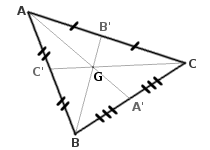

In [ ]:
import math # Pour pouvoir utiliser math.sqrt (racine carrée)

# --- CLASSE 1 : LE POINT ---
class Point:
    def __init__(self, x=0, y=0):
        self.x = x # Coordonnée horizontale
        self.y = y # Coordonnée verticale

    def deplacer(self, nx, ny):
        self.x = nx # On remplace l'ancien x par le nouveau
        self.y = ny # On remplace l'ancien y par le nouveau

# --- CLASSE 2 : LE SEGMENT ---
class Segment:
    def __init__(self, p1, p2):
        self.p1 = p1 # Le premier point du segment
        self.p2 = p2 # Le deuxième point du segment

    def longueur(self):
        # Calcul de la distance entre p1 et p2 (Pythagore)
        return math.sqrt((self.p2.x - self.p1.x)**2 + (self.p2.y - self.p1.y)**2)

# --- CLASSE 3 : LE TRIANGLE (COMME LE RECTANGLE) ---
class Triangle:
    def __init__(self):
        # On met les 3 points vides au départ (Composition)
        self.A = Point(0, 0)
        self.B = Point(0, 0)
        self.C = Point(0, 0)

        # On crée les 3 côtés en reliant les points A, B et C
        self.AB = Segment(self.A, self.B)
        self.BC = Segment(self.B, self.C)
        self.CA = Segment(self.C, self.A)

    def perimetre(self):
        # Le périmètre est la somme des 3 segments
        return self.AB.longueur() + self.BC.longueur() + self.CA.longueur()

    def barycentre(self):
        # G est la moyenne des positions des 3 points
        x_g = (self.A.x + self.B.x + self.C.x) / 3
        y_g = (self.A.y + self.B.y + self.C.y) / 3
        return Point(x_g, y_g) # On renvoie un objet Point pour G

### B - Tester la classe **Triangle** en créant 3 points **A**, **B** et **C**, puis en déplaçant A vers **(3, 2)**, B vers **(7, 5)**, et C vers **(5, 8)**, puis en affichant le  périmetre du triangle **ABC** et les coordonnées du point **G**, centre de gravité de ce triangle.

In [ ]:
# pour testeer la classe triangle
ABC = Triangle()

# pour deplacé les points A, B et C vers les coordonnées voulues
ABC.A.deplacer(3, 2)
ABC.B.deplacer(7, 5)
ABC.C.deplacer(5, 8)

# pour avoir les calculs
p = ABC.perimetre()
g = ABC.barycentre()

print(f"Périmètre du triangle ABC : {p}")
print(f"Coordonnées de G : {g.x}, {g.y}")

Périmètre du triangle ABC : 14.930106595800748
Coordonnées de G : 5.0, 5.0


### C - Afficher le triangle ABC et son centre de gravité dans un graphe en utilisant la bibliothèque MatPlotLib


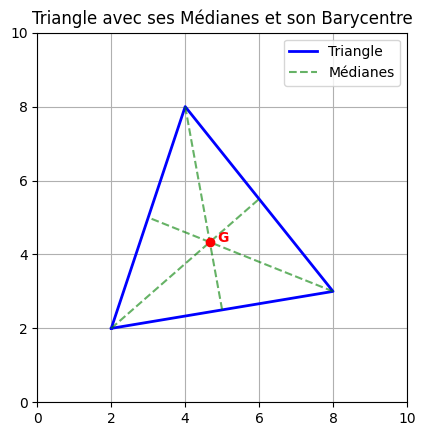

In [ ]:
import matplotlib.pyplot as plt

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

class Triangle:
    def __init__(self, pA, pB, pC):
        self.A, self.B, self.C = pA, pB, pC

ABC = Triangle(Point(2, 2), Point(8, 3), Point(4, 8))

g_x = (ABC.A.x + ABC.B.x + ABC.C.x) / 3
g_y = (ABC.A.y + ABC.B.y + ABC.C.y) / 3

mBC_x, mBC_y = (ABC.B.x + ABC.C.x)/2, (ABC.B.y + ABC.C.y)/2
mAC_x, mAC_y = (ABC.A.x + ABC.C.x)/2, (ABC.A.y + ABC.C.y)/2
mAB_x, mAB_y = (ABC.A.x + ABC.B.x)/2, (ABC.A.y + ABC.B.y)/2

x_list = [ABC.A.x, ABC.B.x, ABC.C.x, ABC.A.x]
y_list = [ABC.A.y, ABC.B.y, ABC.C.y, ABC.A.y]
plt.plot(x_list, y_list, 'b-', linewidth=2, label="Triangle")

plt.plot([ABC.A.x, mBC_x], [ABC.A.y, mBC_y], 'g--', alpha=0.6, label="Médianes")
plt.plot([ABC.B.x, mAC_x], [ABC.B.y, mAC_y], 'g--', alpha=0.6)
plt.plot([ABC.C.x, mAB_x], [ABC.C.y, mAB_y], 'g--', alpha=0.6)

plt.plot(g_x, g_y, 'ro')
plt.text(g_x + 0.2, g_y, 'G', color='red', fontweight='bold')

plt.grid(True)
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Triangle avec ses Médianes et son Barycentre")
plt.legend()
plt.show()